In [1]:
import open3d as o3d
import numpy as np

# 建立範例點雲
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(np.random.rand(1000, 3))
pcd.paint_uniform_color([0.2, 0.8, 1.0])  # 藍綠色點雲

# 定義按鍵事件函式
def zoom_in_fov(vis):
    ctr = vis.get_view_control()
    if hasattr(ctr, "change_field_of_view"):
        ctr.change_field_of_view(-5.0)   # 負值 = 視角更窄 = 近似放大
        vis.update_renderer()
    return False

def zoom_out_fov(vis):
    ctr = vis.get_view_control()
    if hasattr(ctr, "change_field_of_view"):
        ctr.change_field_of_view(+5.0)   # 視角更廣 = 近似縮小
        vis.update_renderer()
    return False


def toggle_color(vis):
    # 切換點雲顏色
    pcd.paint_uniform_color(np.random.rand(3))
    vis.update_geometry(pcd)
    print("🎨 Changed Color")
    return False

def save_screenshot(vis):
    vis.capture_screen_image("screenshot.png")
    print("📸 Screenshot saved as screenshot.png")
    return False

def downsample(vis):
    """按 D 鍵進行 voxel downsample"""
    global pcd
    # 執行 downsample
    downsampled_pcd = pcd.voxel_down_sample(voxel_size=0.02)
    pcd = downsampled_pcd
    # 更新視窗顯示
    vis.clear_geometries()
    vis.add_geometry(pcd)
    vis.poll_events()
    vis.update_renderer()
    print(f"Downsampled! Current points: {len(pcd.points)}")
    return False

# 建立快捷鍵對應字典
key_to_callback = {
    ord("Z"): zoom_in_fov,      # 按 Z 放大fov
    ord("X"): zoom_out_fov,     # 按 X 縮小fov
    ord("C"): toggle_color,     # 按 C 換顏色
    ord("S"): save_screenshot,  # 按 S 截圖
    ord("D"): downsample,       # 按 D 進行 downsample
}

# 啟動可互動視窗
o3d.visualization.draw_geometries_with_key_callbacks(
    [pcd],
    key_to_callback=key_to_callback,
    window_name="Interactive PointCloud Example",
    width=960,
    height=720
)

2025-11-06 20:57:11.776 python[17119:10385147] TSM AdjustCapsLockLEDForKeyTransitionHandling - _ISSetPhysicalKeyboardCapsLockLED Inhibit


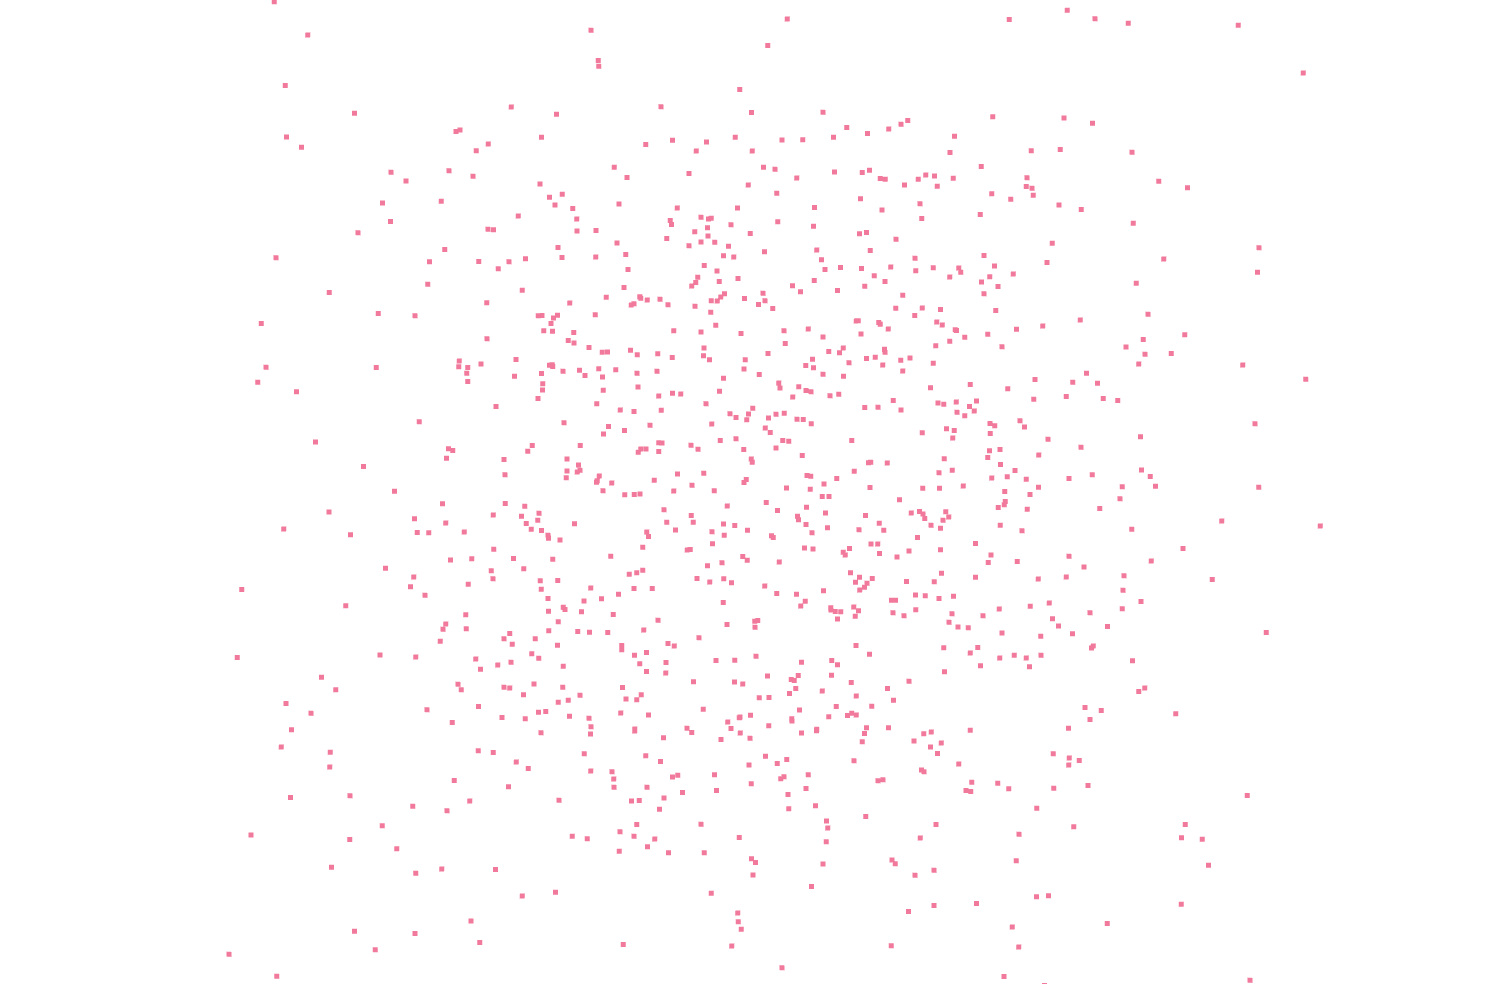

In [2]:
pcd_point_cloud = o3d.data.PCDPointCloud()
pcd = o3d.io.read_point_cloud(pcd_point_cloud.path)

plane_model, inliers = pcd.segment_plane(distance_threshold=0.03, #微調視點雲尺度
                                         ransac_n=3,
                                         num_iterations=3000)
[a, b, c, d] = plane_model
print(f"Plane equation: {a:.2f}x + {b:.2f}y + {c:.2f}z + {d:.2f} = 0")

inlier_cloud = pcd.select_by_index(inliers)
inlier_cloud.paint_uniform_color([1.0, 0, 0])
outlier_cloud = pcd.select_by_index(inliers, invert=True)
o3d.visualization.draw_geometries([inlier_cloud, outlier_cloud],
                                  zoom=0.8,
                                  front=[-0.4999, -0.1659, -0.8499],
                                  lookat=[2.1813, 2.0619, 2.0999],
                                  up=[0.1204, -0.9852, 0.1215])

Plane equation: -0.05x + -0.10y + 0.99z + -1.08 = 0


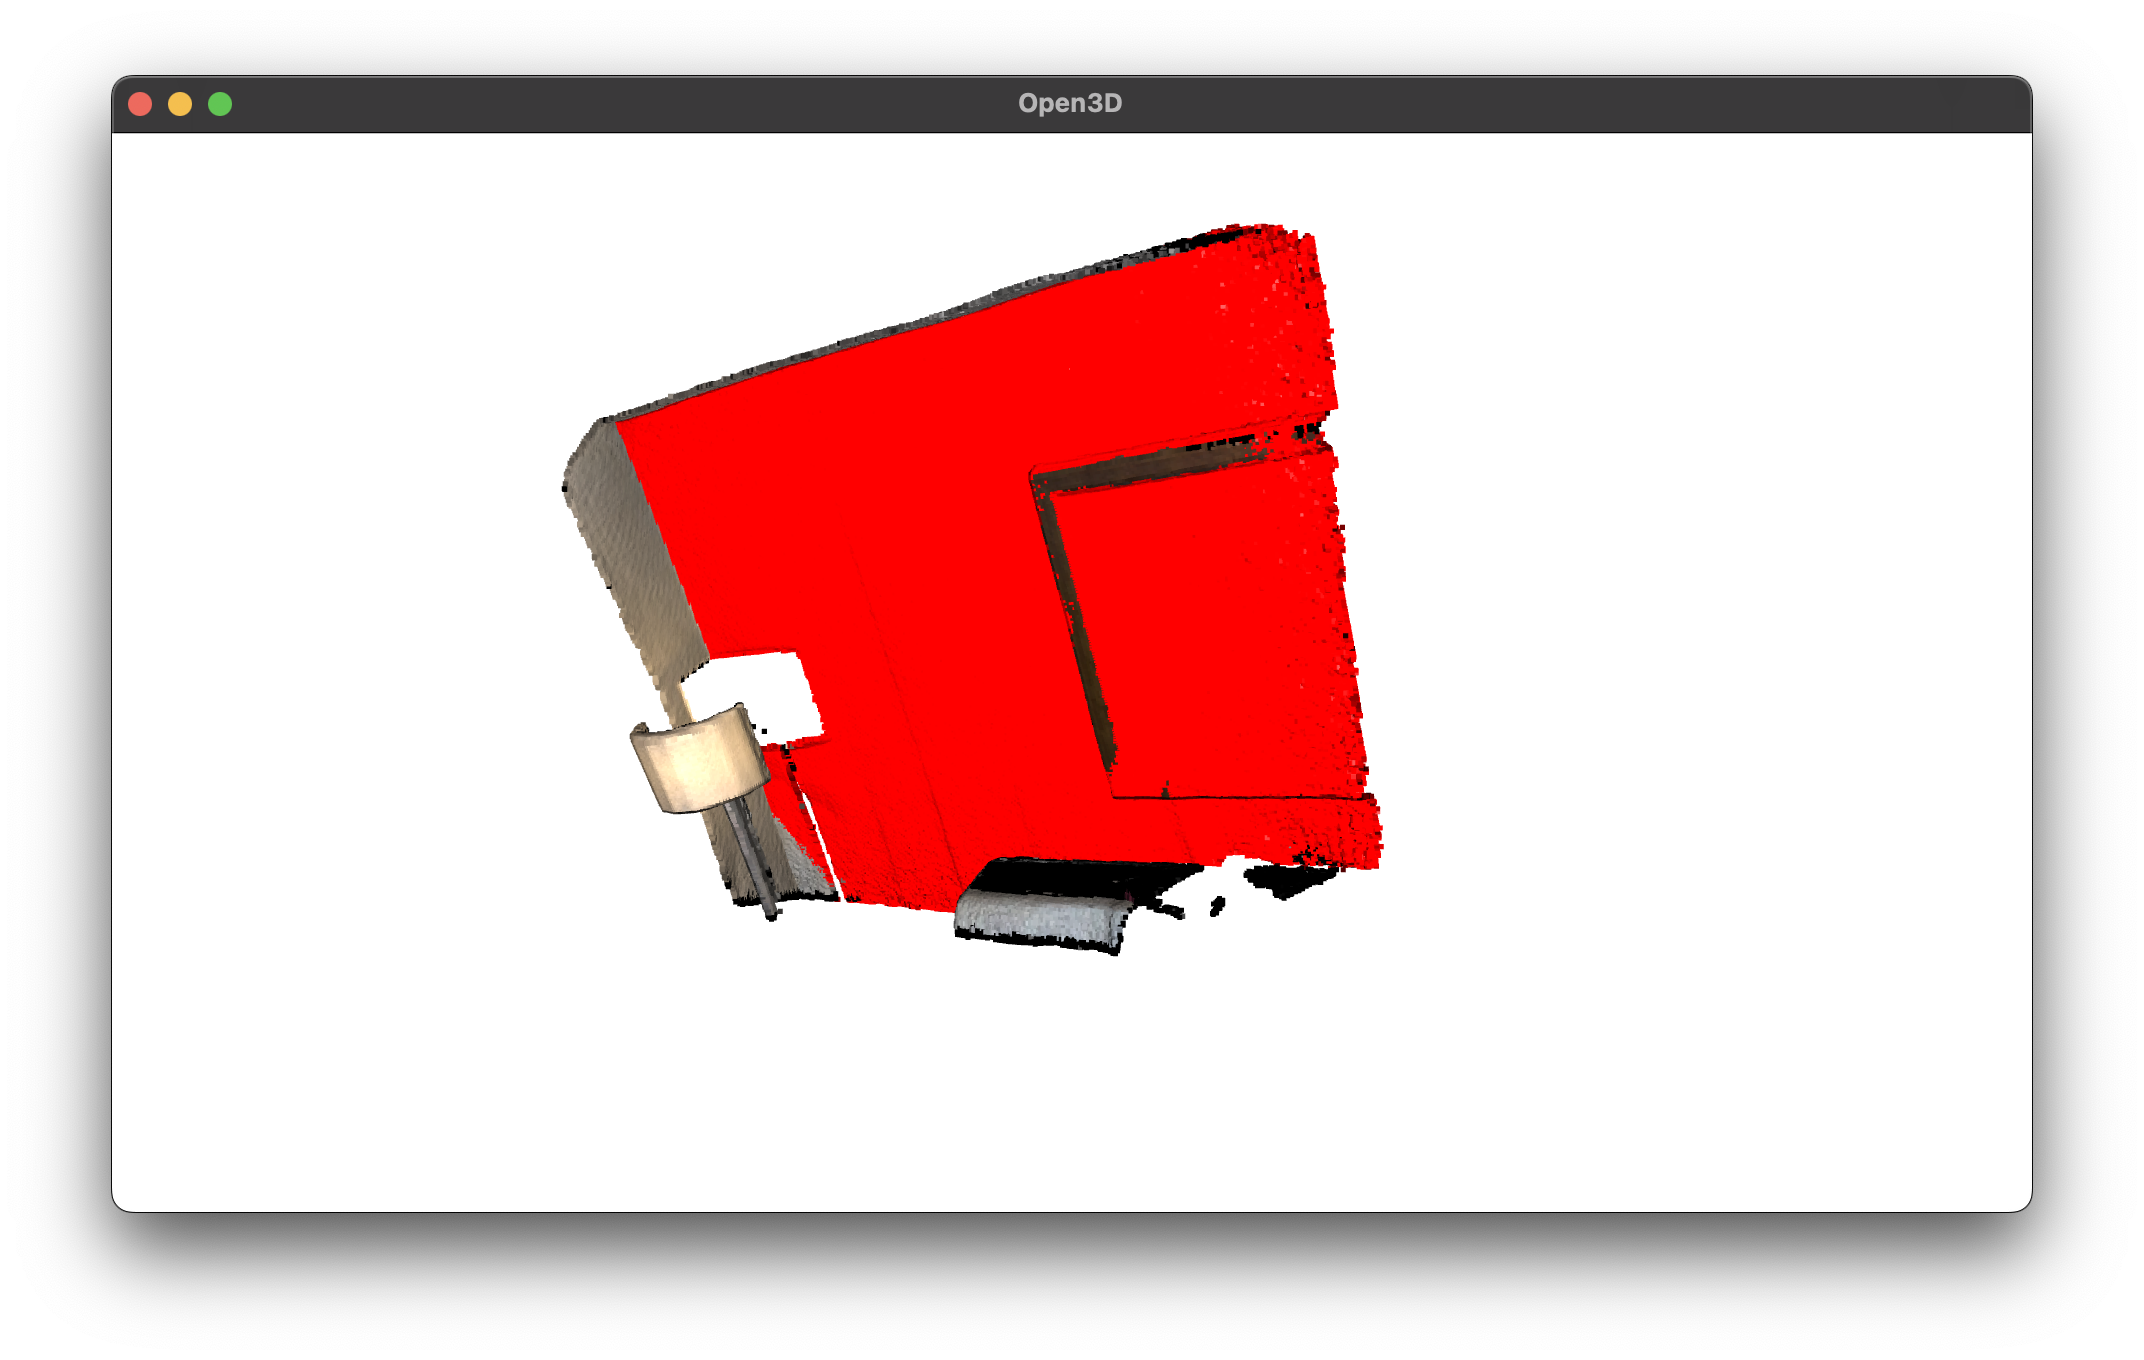